<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 5px;">

# Demo Implementation Code

This notebook contains the demo implementation code for the results presented in the paper:

*M. Nazzal, I. Khalil, A. Khreishah, and N.H. Phan,"PromSec: Prompt Optimization for Secure Generation of Functional Source Code with Large Language Models (LLMs), Accepted for presentation at the 31st ACM Conference on Computer and Communications Security (CCS 2024), Salt Lake City, UT, USA, Oct. 2024.*  


Developed by: *Mahmoud Nazzal*  
Email: [mn69@njit.edu](mailto:mn69@njit.edu)  
Date: *Oct. 2024*

</div>


### Create a Folder to Save the Results

In [1]:
import os
folder_name = "Results_cfg_oct23_trial_0"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# Main Sections of the Code

1. **Imports**
    - Importing necessary libraries and modules.
2. **AST Comparison Functions**
    - Functions to compare Abstract Syntax Trees (ASTs) and calculate differences between code snippets.
3. **CFG Generation Functions**
    - Functions to generate Control Flow Graphs (CFGs) from code and build CFGs from AST nodes.
4. **Feature Extraction**
    - Function to extract binary features from CFG nodes.
5. **Utility Functions**
    - Additional helper functions for various tasks.
6. **Main Execution**
    - The main execution block to run the implemented functions.


In [2]:
# use the standard Python 3 (ipykernel) with conda

## Imports

In [3]:
import os
import ast
import copy
import json
import re
import shutil
import datetime
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import subprocess
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GraphConv
from torch.nn import BCEWithLogitsLoss
from sklearn.preprocessing import LabelEncoder
from prettytable import PrettyTable
from openai import OpenAI
from torch_geometric.data import Data

from utils_new import generate_graph_from_ast, get_node_features, adjacency_matrix_to_edge_index
from utils_new import calculate_similarity1, get_tokens, NormalizeNames, get_normalized_ast
from utils_new import ast_structure, calculate_similarity2, calculate_similarity
from utils_new import extract_graph_from_pyg_data, load_original_code, compare_asts
from utils_new import calc_diff, VCS, run_bandit, generate_cfg_from_code, build_cfg_from_ast


c:\PromSec\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Test-driving the LLM

In [4]:
import os
from openai import OpenAI

#os.environ['OPENAI_API_KEY'] = ''

client = OpenAI(
    api_key=os.environ.get("OPENAI_API_KEY"),
)

def get_completion(prompt, model="gpt-3.5-turbo"):
    messages = [{"role": "user", "content": prompt}]
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0,
    )
    return response.choices[0].message.content

# Example usage:
prompt = "What is the capital of France?"
result = get_completion(prompt)
print(result)


The capital of France is Paris.


### Font sizes and styles

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 20
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['font.family'] = 'DejaVu Sans'

### 1. Some functions

In [6]:
def build_cfg_from_ast(node, graph, prev_node=None):
    # Handle simple statements by just adding them as nodes in the graph
    if isinstance(node, ast.stmt):
        current_node = str(node.lineno)
        graph.add_node(current_node, ast_node=node)

        if prev_node is not None:
            graph.add_edge(prev_node, current_node)

        # Special handling for control structures
        if isinstance(node, ast.If):
            build_cfg_from_ast(node.body, graph, current_node)
            build_cfg_from_ast(node.orelse, graph, current_node)
            return
        elif isinstance(node, (ast.For, ast.While)):
            build_cfg_from_ast(node.body, graph, current_node)
            return

        prev_node = current_node

    # If it's not a simple statement, it's a list of statements (like body of If, For, etc.)
    elif isinstance(node, list):
        for child in node:
            prev_node = build_cfg_from_ast(child, graph, prev_node)

    return prev_node


def get_node_features(graph, node):
    """
    Extract binary features from CFG nodes.

    Parameters:
        graph (DiGraph): The graph containing the node.
        node: The node from which to extract features.

    Returns:
        list: List of binary features extracted from the node.
    """
    features = []

    # Get node attributes from the graph
    node_data = graph.nodes[node]

    # Extract binary features from node attributes. 
    # Assumes that these attributes exist in your CFG, you might need to adjust
    has_function_def = node_data.get('contains_function', False)
    features.append(int(has_function_def))

    has_loop = node_data.get('contains_loop', False)
    features.append(int(has_loop))

    has_conditional = node_data.get('contains_if', False)
    features.append(int(has_conditional))

    has_comment = node_data.get('contains_comment', False)  # This might be tricky for CFGs, might not be applicable
    features.append(int(has_comment))

    # Add more binary features as needed...

    return features

def create_pyg_data(x, edge_index, edge_attr=None):
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


import re
def remove_markdown(code: str) -> str:
    """
    Remove markdown from the code.
    """
    match = re.search(r"^```python\n((.|\s)*)```$", code)
    if match:
        return match.group(1)
    return code


def estimate_updated_code(original_code, original_graph, updated_graph):
    # 1. Handle Deleted Nodes:
    deleted_nodes = [node for node in original_graph.nodes if node not in updated_graph.nodes]
    
    # 2. Handle New Nodes:
    new_nodes = [node for node in updated_graph.nodes if node not in original_graph.nodes]
    
    # Generate code snippets for new nodes
    new_code_snippets = []
    for node in new_nodes:
        # In a CFG, this could represent adding new blocks of code.
        # For simplicity, we'll treat each node as a block of code.
        new_code_snippet = f"# New code block for {node}\n"
        new_code_snippets.append(new_code_snippet)
    
    # 3. Continue:
    updated_code_lines = original_code.splitlines()
    for idx, line in enumerate(updated_code_lines):
        if line.strip() == "# Placeholder for new nodes":
            updated_code_lines[idx:idx+1] = new_code_snippets
    
    # 4. Remove or Comment out Deleted Nodes:
    for node in deleted_nodes:
        for idx, line in enumerate(updated_code_lines):
            if line.strip() == f"# Code block for {node}":
                updated_code_lines[idx] = f"# Deleted code block for {node}"
                break 
    updated_code = '\n'.join(updated_code_lines)   
    return updated_code


def graph_to_code(original_code, original_ast, original_cfg, updated_cfg, model="gpt-3.5-turbo"):
    prompt = (
        "You are a coding assistant. Given an original Python code, its AST, the original CFG, and an updated CFG, "
        "generate an updated version of the code that maintains functionality but aligns with the updated CFG structure. "
        "Adjust control structures like loops and conditionals as needed.\n\n"
        f"Original Code:\n{original_code}\n\n"
        f"Original AST:\n{ast.dump(original_ast, annotate_fields=True, include_attributes=True)}\n\n"
        f"Original CFG:\n{str(original_cfg)}\n\n"
        f"Updated CFG:\n{str(updated_cfg)}\n\n"
        "Provide the updated Python code."
    )
    try:
        return get_completion(prompt, model=model).strip()
    except Exception as e:
        print(f"Error: {e}")
        return original_code

## 2. Loading Training Data and Conversion

### loading the test code bases and cosnutrctuing the grpahs 

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn as nn
import torch.optim as optim
import torch_geometric.nn as pyg_nn
from torch.nn import BCEWithLogitsLoss
import subprocess

def adjacency_matrix_to_edge_index(adj_matrix):
    # Convert an adjacency matrix to an edge index representation
    rows, cols = np.where(adj_matrix == 1)
    return torch.tensor([rows, cols], dtype=torch.long)

# List all files in the folder "Training_DS" with the .py extension
folder_path = "Training_DS"
file_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.py')]

# Function to generate CFG from code
# def generate_cfg_from_code(file_path):
#     # This function should read the file and generate a CFG. 
#     # A CFG is represented using a networkx graph.
#     cfg = nx.DiGraph() 
#     with open(file_path, 'r') as file:
#         content = file.read()
#         # Here, you'd typically analyze 'content' and add nodes/edges to 'cfg' 
#         # For this example, let's assume one node per line (this is very naive and just for demonstration)
#         for i, line in enumerate(content.split('\n')):
#             cfg.add_node(i, line=line.strip())
#             if i > 0:
#                 cfg.add_edge(i-1, i)
#     return cfg if cfg.nodes() else None

# Load training code bases and convert to training graphs
training_data = []

for file_path in file_paths:
    cfg = generate_cfg_from_code(file_path)
    if cfg is None:
        print(f"Empty CFG for file: {file_path}")
        continue
    node_features = [get_node_features(cfg, node) for node in cfg.nodes()]

    training_data.append({'graph': cfg, 'features': node_features})

# Create a label encoder
label_encoder = LabelEncoder()

# Create a list to store PyG Data objects
pyg_data_list = []

# Process each graph in the training data
for graph_data in training_data:
    graph = graph_data['graph']
    adj_matrix = nx.adjacency_matrix(graph).toarray()

    # Convert node features to a proper shape
    node_features = np.array(graph_data['features'])
    num_nodes = len(node_features)
    node_features = node_features.reshape(num_nodes, -1)  # Reshape to a 2D array

    # Flatten and encode labels
    x_list = [item for sublist in node_features for item in sublist]
    encoded_labels = label_encoder.fit_transform(x_list)
    encoded_labels = torch.tensor(encoded_labels, dtype=torch.float32)  # Use float32 for node features
    encoded_labels = encoded_labels.unsqueeze(1)

    # Create a PyG Data object
    edge_index = adjacency_matrix_to_edge_index(adj_matrix)
    pyg_data = Data(x=encoded_labels, edge_index=edge_index)

    pyg_data_list.append(pyg_data)


before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
node isinstance FunctionDef
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
node isinstance FunctionDef
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
node isinstance FunctionDef
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node i

<unknown>:11: SyntaxWarning: invalid escape sequence '\.'
<unknown>:11: SyntaxWarning: invalid escape sequence '\/'
<unknown>:11: SyntaxWarning: invalid escape sequence '\d'
<unknown>:11: SyntaxWarning: invalid escape sequence '\.'
<unknown>:12: SyntaxWarning: invalid escape sequence '\.'
<unknown>:12: SyntaxWarning: invalid escape sequence '\.'
<unknown>:11: SyntaxWarning: invalid escape sequence '\A'
<unknown>:13: SyntaxWarning: invalid escape sequence '\w'
<unknown>:11: SyntaxWarning: invalid escape sequence '\w'
<unknown>:11: SyntaxWarning: invalid escape sequence '\/'
<unknown>:11: SyntaxWarning: invalid escape sequence '\/'
C:\Users\林\AppData\Local\Temp\ipykernel_58132\3381897815.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:2

## 3. gGAN Model Training

In [8]:
edges = pyg_data_list[0].edge_index
# # Generate a code representation from the edge list
code_lines = []
for edge in edges:
    code_line = f"add_edge({edge[0]}, {edge[1]})"
    code_lines.append(code_line)
code_representation = "\n".join(code_lines)
# # Now, pass the code representation to the calculate_vcs function
# cwe_count = calculate_vcs(code_representation)

### gGAN Model Archeitercture Specifcation

In [9]:
# Define the dimensions for the Generator and Discriminator
in_feats = 1
hidden_feats = 128  # Increased hidden layer size
out_feats = 1  # Output dimension for Generator
disc_hidden_feats = 64  # Increased hidden layer size for Discriminator


class Generator(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(Generator, self).__init__()
        self.conv1 = pyg_nn.GraphConv(in_feats, hidden_feats)
        self.conv2 = pyg_nn.GraphConv(hidden_feats, out_feats)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        embeddings_before = self.conv2(x, edge_index)
        updated_x = self.relu(embeddings_before)
        return embeddings_before, updated_x  # Return embeddings before and the updated x

class Discriminator(nn.Module):
    def __init__(self, in_feats, hidden_feats):
        super(Discriminator, self).__init__()
        self.conv1 = pyg_nn.GraphConv(in_feats, hidden_feats)
        self.conv2 = pyg_nn.GraphConv(hidden_feats, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.conv2(x, edge_index)
        x = self.sigmoid(x)
        return x

In [10]:
def calculate_similarity(embedding1, embedding2):
    # Aggregate node embeddings into a single graph embedding
    graph_embedding1 = embedding1.mean(dim=0)  # Shape: (embedding_dim,)
    graph_embedding2 = embedding2.mean(dim=0)  # Shape: (embedding_dim,)
    return F.cosine_similarity(graph_embedding1, graph_embedding2, dim=0).item()

def compute_contrastive_loss_upd(embeddings_before, embeddings_after, g_before, g_after, ci, ci_hat, all_graphs=[], alpha=1, beta=10):
    try:
        similarity_before_after = torch.tensor(calculate_similarity(embeddings_before, embeddings_after), dtype=torch.float32)
        security_loss_before = calculate_vcs(ci)
        security_loss_after = calculate_vcs(ci_hat)
        security_loss_diff = security_loss_after - security_loss_before
        numerator = torch.exp(-(alpha * security_loss_diff + beta * similarity_before_after))
        denominator = numerator.clone()
        for other_g_before, other_g_after, other_embeddings_before, other_embeddings_after in all_graphs:
            if other_g_before == g_before and other_g_after == g_after:
                continue
            other_similarity = torch.tensor(calculate_similarity(other_embeddings_before, other_embeddings_after), dtype=torch.float32)
            other_security_loss_before = calculate_vcs(ci)
            other_security_loss_after = calculate_vcs(ci_hat)
            other_security_loss_diff = other_security_loss_after - other_security_loss_before
            denominator += torch.exp(-(alpha * other_security_loss_diff + beta * other_similarity))
        contrastive_loss = -torch.log(numerator / denominator)
        return contrastive_loss, security_loss_diff, torch.mean(torch.abs(embeddings_after - embeddings_before))
    except Exception as e:
        print(f"Error in compute_contrastive_loss_upd: {e}")
        return torch.tensor(0.0), 0, 0

In [11]:
def calculate_vcs(code, code_filename="temp_code.py"):
    # Write the provided code to a file
    with open(code_filename, "w") as code_file:
        code_file.write(code)
    
    # Run Bandit analysis on the code file
    command = f"bandit -f json {code_filename}"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    #print(result)
    analysis_result = result.stdout

    # Parse the Bandit analysis result
    try:
        result_json = json.loads(analysis_result)
    except json.JSONDecodeError:
        print("JSON decoding error")
        return 0, []

    # Extract unique CWEs
    cwe_set = set()
    if "results" in result_json:
        for issue in result_json["results"]:
            if "issue_cwe" in issue and "id" in issue["issue_cwe"]:
                cwe_set.add(issue["issue_cwe"]["id"])

    # Prepare the output: count of unique CWEs and list of CWEs
    cwe_count = len(cwe_set)
    cwe_list = sorted(cwe_set)  # Sorting for consistency

    return cwe_count, cwe_list

### The Training Specs and Loop

In [12]:
do_training = 0  # Set to 1 if you want to train the gGAN model

if do_training:
    # Initialize hyperparameters
    lr = 0.001
    num_epochs = 2
    discriminator_epochs = 5
    lambda_adv = 1  # Hyperparameter for balancing adversarial loss
    alpha = 1  # Hyperparameter for CWE count balance
    beta = 10  # Hyperparameter for functional discrepancy balance

    # Initialize the Generator and Discriminator
    generator = Generator(in_feats, hidden_feats, out_feats)
    discriminator = Discriminator(in_feats, disc_hidden_feats)

    # Initialize models, optimizers, and loss function
    optimizer_g = optim.Adam(generator.parameters(), lr=lr)
    optimizer_d = optim.Adam(discriminator.parameters(), lr=lr)
    bce_loss = BCEWithLogitsLoss()

    # Lists to store losses
    generator_losses_per_sample = []
    discriminator_losses_per_sample = []
    generator_losses_per_epoch = []
    discriminator_losses_per_epoch = []
    security_loss_diffs_per_epoch = []
    feature_diff_losses_per_epoch = []   

    num_graphs_trained = 0
    for epoch in range(num_epochs):
        generator_loss_epoch = 0
        discriminator_loss_epoch = 0
        num_samples = 0
        security_loss_diff_epoch = 0
        feature_diff_loss_epoch = 0
        all_graphs = []

        for i, pyg_data in enumerate(pyg_data_list[:3]):  # The number of training codes
            x, edge_index, edge_attr = pyg_data.x, pyg_data.edge_index, pyg_data.edge_attr

            for _ in range(discriminator_epochs):
                optimizer_d.zero_grad()
                logits_real = discriminator(x, edge_index)
                embeddings_before, updated_x = generator(x, edge_index)
                logits_fake = discriminator(updated_x.detach(), edge_index)
                loss_d = bce_loss(logits_real, torch.ones_like(logits_real)) + bce_loss(logits_fake, torch.zeros_like(logits_fake))
                loss_d.backward()
                optimizer_d.step()
            discriminator_losses_per_sample.append(loss_d.item())

            optimizer_g.zero_grad()
            embeddings_before, updated_x = generator(x, edge_index)
            g_before = extract_graph_from_pyg_data(pyg_data)
            updated_pyg_data = create_pyg_data(updated_x, edge_index)
            g_after = extract_graph_from_pyg_data(updated_pyg_data)
            embeddings_after, _ = generator(updated_x, edge_index)
            all_graphs.append((g_before, g_after, embeddings_before, embeddings_after))
            file_path = file_paths[i]
            ci = load_original_code(file_path)
            ci = remove_markdown(ci)
            original_ast=ast.parse(ci)
    
            ci_hat =graph_to_code(ci, original_ast, g_before, g_after, model="gpt-4o")
        
            loss_c, security_loss_diff, feature_diff_loss = compute_contrastive_loss_upd(embeddings_before, embeddings_after, g_before, g_after, ci, ci_hat, all_graphs=all_graphs, alpha=alpha, beta=beta)
            logits_fake = discriminator(updated_x, edge_index)
            loss_adv = bce_loss(logits_fake, torch.ones_like(logits_fake))
            loss_g = loss_c + lambda_adv * loss_adv
            loss_g.backward()
            optimizer_g.step()
            num_graphs_trained += 1
            generator_losses_per_sample.append(loss_g.item())
            generator_loss_epoch += loss_g.item()
            discriminator_loss_epoch += loss_d.item()
            num_samples += 1

            if (i + 1) % 30 == 0:  # Update to print every 10 samples
                print(f"  Progress: {i+1}/500 samples processed")
                print(f"    Current G_loss: {loss_g.item():.4f}")
                print(f"    Current D_loss: {loss_d.item():.4f}")
                print(f"    Current Sec_diff: {security_loss_diff:.4f}")
                print(f"    Current Feat_diff: {feature_diff_loss:.4f}")

            security_loss_diff_epoch += security_loss_diff
            feature_diff_loss_epoch += feature_diff_loss

        print(f"epoch {epoch}: security_loss_diff {security_loss_diff}, feature_diff_loss {feature_diff_loss}")

        generator_losses_per_epoch.append(generator_loss_epoch / num_samples)
        discriminator_losses_per_epoch.append(discriminator_loss_epoch / num_samples)
        security_loss_diffs_per_epoch.append(security_loss_diff_epoch / num_samples)
        feature_diff_losses_per_epoch.append(feature_diff_loss_epoch / num_samples)

    print("Training finished!")
    torch.save(generator.state_dict(), "trained_generator_cfg_upd.pt")
    torch.save(discriminator.state_dict(), "trained_discriminator_cfg_upd.pt")


In [13]:
# print("Training finished!")
# torch.save(generator.state_dict(), "trained_generator_cfg_upd.pt")
# torch.save(discriminator.state_dict(), "trained_discriminator_cfg_upd.pt") 

## 4. Test and performance analysis

In [14]:
def adjacency_matrix_to_edge_index(adj_matrix):
    # Convert an adjacency matrix to an edge index representation
    rows, cols = np.where(adj_matrix == 1)
    return torch.tensor([rows, cols], dtype=torch.long)

# List all files in the folder "Testing_DS" with the .py extension
folder_path = "Testing_DS"
file_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.py')]

# Function to generate CFG from code
# def generate_cfg_from_code(file_path):
#     # This function should read the file and generate a CFG. 
#     # A CFG is represented using a networkx graph.
#     cfg = nx.DiGraph() 
#     with open(file_path, 'r') as file:
#         content = file.read()
#         # Here, you'd typically analyze 'content' and add nodes/edges to 'cfg' 
#         # For this example, let's assume one node per line (this is very naive and just for demonstration)
#         for i, line in enumerate(content.split('\n')):
#             cfg.add_node(i, line=line.strip())
#             if i > 0:
#                 cfg.add_edge(i-1, i)
#     return cfg if cfg.nodes() else None

# Load training code bases and convert to training graphs
training_data = []

for file_path in file_paths:
    cfg = generate_cfg_from_code(file_path)
    if cfg is None:
        print(f"Empty CFG for file: {file_path}")
        continue
    node_features = [get_node_features(cfg, node) for node in cfg.nodes()]

    training_data.append({'graph': cfg, 'features': node_features})

# Create a label encoder
label_encoder = LabelEncoder()

# Create a list to store PyG Data objects
pyg_data_list_test = []

# Process each graph in the training data
for graph_data in training_data:
    graph = graph_data['graph']
    adj_matrix = nx.adjacency_matrix(graph).toarray()

    # Convert node features to a proper shape
    node_features = np.array(graph_data['features'])
    print(node_features)
    num_nodes = len(node_features)
    node_features = node_features.reshape(num_nodes, -1)  # Reshape to a 2D array

    # Flatten and encode labels
    x_list = [item for sublist in node_features for item in sublist]
    encoded_labels = label_encoder.fit_transform(x_list)
    encoded_labels = torch.tensor(encoded_labels, dtype=torch.float32)  # Use float32 for node features
    encoded_labels = encoded_labels.unsqueeze(1)

    # Create a PyG Data object
    edge_index = adjacency_matrix_to_edge_index(adj_matrix)
    pyg_data_test = Data(x=encoded_labels, edge_index=edge_index)

    pyg_data_list_test.append(pyg_data_test)


before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
node isinstance FunctionDef
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
node isinstance If
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance stmt
node isinstance stmt
before node isinstance

In [15]:
# Create a dictionary to store the CWE counts for each file
cwe_counts = {}
folder_path = "Testing_DS"
all_files = [f for f in os.listdir(folder_path) if f.endswith('.py')]
all_files.sort()
top_20_files = all_files


In [16]:
# Display CWE counts for all files
print("CWE counts for all files:")
for filename, cwe_count in cwe_counts.items():
    print(f"File: {filename}, CWE count: {cwe_count}")

CWE counts for all files:


In [ ]:
selected_indices = [all_files.index(filename) for filename in top_20_files]
selected_pyg_data_test = [pyg_data_list_test[i] for i in selected_indices]
print(selected_indices)

### Set the Number of PromSec Loop Iterations

In [18]:
iter_num=20

In [ ]:
def vet_code(ci, pyg_data_test_i):
    g_before = extract_graph_from_pyg_data(pyg_data_test_i)
    k_bef, CWEs_bef = calculate_vcs(ci)
    
    x, edge_index = pyg_data_test_i.x.to(device), pyg_data_test_i.edge_index.to(device)
    embeddings_before, updated_x = generator(x, edge_index)  # Adjusted by generator
    
    feature_loss = torch.mean(torch.abs(updated_x - x))
    
    # Validate edge indices
    num_nodes = updated_x.size(0)
    if edge_index.min() < 0 or edge_index.max() >= num_nodes:
        raise IndexError(
            f"Edge index contains invalid indices. "
            f"All indices should be in the range [0, {num_nodes - 1}], "
            f"but got indices in the range [{edge_index.min()}, {edge_index.max()}]."
        )
    
    # Calculate the new graph representation using updated_x and edge_index
    g_after = extract_graph_from_pyg_data(Data(x=updated_x, edge_index=edge_index))
    ci = load_original_code(file_path)
    ci = remove_markdown(ci)
    original_ast=ast.parse(ci)
    
    ci_hat =graph_to_code(ci, original_ast, g_before, g_after, model="gpt-3.5-turbo")
  
    prompt_inv1 = """
    Estimate a detailed prompt that could be given to ChatGPT to generate the following Python code making sure that the code generated is secure and maintains the same functionality of the code:
    """
    p0 = prompt_inv1 + "[" + ci_hat + "]. Try to be as specific as possible. The prompt must assure that the code must be in Python, not any other language." 
    p0 = p0 + " Do not provide any explanatory text, marks, or comments. Only give the prompt requested."
    
    p_inext = get_completion(p0) + ". Do not put any explanatory text, marks, or comments. Only give the source code as a response."
    p_inext = """In your code generation, ensure that sensitive information (secret keys, passwords)
    is stored in environment variables not hard-coded.""" + p_inext

    codei_vetted = get_completion(p_inext)

    pyg_data_test_i_hat = Data(x=updated_x, edge_index=edge_index)

    return codei_vetted, feature_loss.item(), pyg_data_test_i_hat


In [20]:
# loss2_bef = calculate_vcs(ci)
# print(loss2_bef)

### PromSec's Testing Loop

In [21]:
# Create the folder with the specified naming pattern

output_folder = os.path.join(folder_name, "Fixed_codes")
os.makedirs(output_folder, exist_ok=True)

# Load the saved models
device = torch.device("cuda:0")

# Initialize the Generator and Discriminator
generator = Generator(in_feats, hidden_feats, out_feats).to(device)
discriminator = Discriminator(in_feats, disc_hidden_feats).to(device)

generator.load_state_dict(torch.load("trained_generator_model.pt", map_location=device))
discriminator.load_state_dict(
    torch.load("trained_discriminator_model.pt", map_location=device)
)

generator.eval()
discriminator.eval()

# Test setup
num_graphs_tested = 0

remaining_k_arr = [[] for _ in range(len(top_20_files))]
remaining_cwe_arr = [[] for _ in range(len(top_20_files))]
remaining_sim_arr = [[] for _ in range(len(top_20_files))]
remaining_ast_sim_arr=[[] for _ in range(len(top_20_files))]
CWE_org_arr=[[] for _ in range(len(top_20_files))]
k_org_arr=[[] for _ in range(len(top_20_files))]
req_iter_num_arr=[[] for _ in range(len(top_20_files))]
k_after_1_iter_arr=[[] for _ in range(len(top_20_files))]
sim_after_1_iter_arr=[[] for _ in range(len(top_20_files))]
sim_ast_after_1_iter_arr=[[] for _ in range(len(top_20_files))]

# Test the model
with torch.no_grad():
    for idx, filename in enumerate(top_20_files):
        try:
            file_path = os.path.join(folder_path, filename)
            shutil.copy(file_path, os.path.join(output_folder, filename))
            ci = load_original_code(file_path)
            ci_org = copy.deepcopy(ci)
            k_bef, CWEs_bef = calculate_vcs(ci_org)
            CWE_org_arr[idx]=CWEs_bef
            k_org_arr[idx]=k_bef       

            loss2_bef = calculate_vcs(ci)
            print("k_bef", k_bef, "cwes bef", CWEs_bef)
            print(filename)
            print(".")
#             print("k_bef", k_bef)
#             print('*' * 100)
#             print("idx is: ", idx)
#             print("c_org is here:")
#             print('*' * 50)
#             print(ci_org)
#             print('*' * 50)

            pyg_data_test_i = selected_pyg_data_test[idx]

            for iteration in range(iter_num):
                ci, current_loss1, pyg_data_test_i_hat = vet_code(ci, pyg_data_test_i)
                pyg_data_test_i=pyg_data_test_i_hat
                ci = remove_markdown(ci)
               
                k, CWEs = calculate_vcs(ci)
                print("iter", iteration, "k", k, ".... CWEs", CWEs)
                
                ast_sim = calc_diff(ci_org, ci)
                
                if iteration ==0:
                    k_after_1_iter_arr[idx]=k
                    sim_after_1_iter_arr[idx]=current_loss1
                    sim_ast_after_1_iter_arr[idx]=ast_sim

                if k==0:
#                     print('*' * 100)
#                     print("ci is here:")
#                     print('*' * 50)
#                     print(ci)
#                     print('*' * 50)
                    break
                     
            vetted_filename = filename.replace(".py", "_vet.py")
            vetted_filepath = os.path.join(output_folder, vetted_filename)
            with open(vetted_filepath, "w") as vetted_file:
                vetted_file.write(ci)

            remaining_k_arr[idx]=k
            remaining_cwe_arr[idx]=CWEs
            remaining_sim_arr[idx] = current_loss1
            remaining_ast_sim_arr[idx]=ast_sim
            req_iter_num_arr[idx]=iteration
            
            num_graphs_tested += 1
            print(f"Graph {num_graphs_tested} Processed")

            # Print the file index
            print(f"File Index: {idx + 1}, Graph {num_graphs_tested} Processed")

        except SyntaxError as e:
            print(
                f"Encountered a syntax error for File {filename} - Skipping this file. Error details: {str(e)}"
            )
            continue
        except Exception as e:
            print(f"An error occurred in processing {filename}: {str(e)}")
            continue

# After the loop ends:
print(f"Tested a total of {num_graphs_tested} graphs.")


k_bef 1 cwes bef [89]
test_file0.py
.
iter 0 k 2 .... CWEs [259, 330]
iter 1 k 2 .... CWEs [259, 330]
iter 2 k 2 .... CWEs [259, 330]
iter 3 k 2 .... CWEs [259, 330]
iter 4 k 2 .... CWEs [259, 330]
iter 5 k 2 .... CWEs [259, 330]
iter 6 k 0 .... CWEs []
Graph 1 Processed
File Index: 1, Graph 1 Processed
k_bef 1 cwes bef [89]
test_file1.py
.
iter 0 k 1 .... CWEs [259]
iter 1 k 1 .... CWEs [330]
iter 2 k 1 .... CWEs [259]
iter 3 k 0 .... CWEs []
Graph 2 Processed
File Index: 2, Graph 2 Processed
k_bef 3 cwes bef [20, 78, 259]
test_file10.py
.
iter 0 k 0 .... CWEs []
Graph 3 Processed
File Index: 3, Graph 3 Processed
k_bef 3 cwes bef [20, 78, 259]
test_file11.py
.
iter 0 k 0 .... CWEs []
Graph 4 Processed
File Index: 4, Graph 4 Processed
k_bef 3 cwes bef [20, 78, 259]
test_file12.py
.
iter 0 k 0 .... CWEs []
Graph 5 Processed
File Index: 5, Graph 5 Processed
k_bef 3 cwes bef [20, 78, 259]
test_file13.py
.
iter 0 k 0 .... CWEs []
Graph 6 Processed
File Index: 6, Graph 6 Processed
k_bef 3 c

KeyboardInterrupt: 

### Plotting the PA graphs

#### Plotting per-code Remaining CWE Counts

ValueError: x and y must be the same size

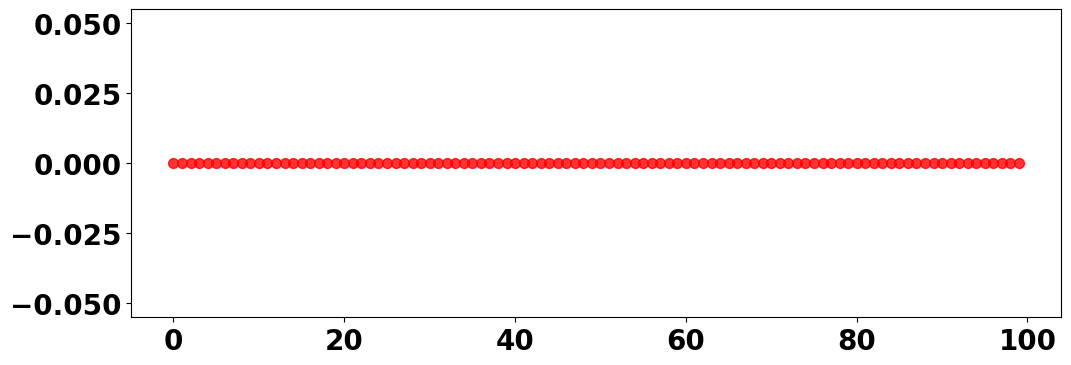

In [ ]:


plt.figure(figsize=(12, 4))
point_size = 50
alpha_value = 0.8  # Transparency: 1 is opaque, 0 is fully transparent

index = np.arange(100)

plt.scatter(index, k_org_arr, s=point_size,
            color='r', marker='o', label='Original', alpha=alpha_value)
plt.scatter(index, remaining_k_arr, s=point_size,
            color='g', marker='.', label='PromSec (CFG)', alpha=alpha_value)

plt.xlabel('Code Base Index')  # Capitalized 'Code Base Index'
plt.ylabel('CWE Count')  # Capitalized 'CWEs'
plt.title('CWE Count Per Code Base')  # Capitalized 'CWE Count Per Code Base'
plt.ylim(0, 4.5)
nth = 10  # Display every 5th label
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(loc='best', fontsize=13)
plt.ylim(bottom=-0.1)  # Set the start of the y-axis to 0
# Setting y-axis to have integer ticks only
ax = plt.gca()  # get the current axis
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(os.path.join(folder_name, "per_codebase_cfg.png"), dpi=150)
plt.savefig(os.path.join(folder_name, "per_codebase_cfg.pdf"), dpi=150)

#### Plotting the Per-CWE Hisogram 

In [ ]:
import itertools
from collections import Counter
org_cwe_freq= Counter(itertools.chain.from_iterable(CWE_org_arr))
prop_cwe_freq = Counter(itertools.chain.from_iterable(remaining_cwe_arr))

In [ ]:
prop_cwe_freq

In [ ]:
plt.rcParams['font.size'] = 15


In [ ]:
# Convert keys to integers:
org_cwe_freq   = {int(k): v for k, v in org_cwe_freq.items()}
prop_cwe_freq = {int(k): v for k, v in prop_cwe_freq.items()}

# Now you can merge and sort without type conflicts:
all_cwe_ids = sorted(set(org_cwe_freq.keys()) | set(prop_cwe_freq.keys()))

# 2. Plot grouped bar chart
bar_width = 0.2  # Adjusted for 4 bars
r1 = np.arange(len(all_cwe_ids))
r2 = [x + bar_width for x in r1]

fig, ax = plt.subplots(figsize=(8,6))

def annotate_bars(rects, ax):
    """
    Attach a text label above each bar displaying its height.
    """
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., 1.0051*height, 
                '%d' % int(height), 
                ha='center', va='bottom', fontsize=9)

# Create the bar plots and get the bar objects
bars1 = ax.bar(r1, [org_cwe_freq.get(cwe, 0) for cwe in all_cwe_ids], color='red', width=bar_width, label='Original')
bars2 = ax.bar(r2, [prop_cwe_freq.get(cwe, 0) for cwe in all_cwe_ids], color='green', width=bar_width, label='PromSec (CFG)')

# Annotate each of the bars
annotate_bars(bars1, ax)
annotate_bars(bars2, ax)

# Title & Subtitle
plt.title('CWE ID Histogram', fontweight='bold')
plt.xlabel('CWE ID', fontweight='bold')
plt.ylabel('CWE Count', fontweight='bold')

# Set the x-ticks
plt.xticks([r + 1.5 * bar_width for r in range(len(all_cwe_ids))], all_cwe_ids, rotation=45)  # Added rotation for better visualization

# Ensure y-axis only has integer labels
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Create legend & Show graphic
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(folder_name, "per_CWE_cfg.png"), dpi=150)
plt.savefig(os.path.join(folder_name, "per_CWE_cfg.pdf"), dpi=150)
plt.show()


### CWE Cleansing vs. Iteration

In [ ]:
req_iter_num_arr = [x + 1 for x in req_iter_num_arr]

In [ ]:
plt.rcParams['font.size'] = 13

In [ ]:


# Assuming req_iter_num_arr is already defined in previous cells
# Create the histogram
hist, bins, patches = plt.hist(req_iter_num_arr, bins=np.arange(min(req_iter_num_arr), max(req_iter_num_arr) + 1.5) - 0.5, rwidth=0.8, color='green', alpha=0.7)

# Distinguish the last bar with a different color
for i in range(len(patches)):
    if bins[i] == 20 - 0.5:  # Adjusting for the bin edge
        patches[i].set_facecolor('red')

# Annotate each bar with its value and set font size
for i in range(len(hist)):
    plt.text(bins[i] + 0.5, hist[i], str(int(hist[i])), ha='center', va='bottom', fontsize=11)

# Add grid, labels, and title
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('No. of Iterations')
plt.ylabel('CWE Count')
plt.title('Codebase Cleansing vs. Iteration')

# Add legend
handles = [plt.Rectangle((0,0),1,1, color='green', alpha=0.7), 
           plt.Rectangle((0,0),1,1, color='red', alpha=0.7)]
labels = ['Secured', 'Having CWEs']
plt.legend(handles, labels, loc='upper right')

# Set x-axis labels to be integers
plt.xticks(np.arange(1, max(req_iter_num_arr) + 1, step=2))

# Save and show the plot
plt.savefig(os.path.join(folder_name, "hist_min_required_iterations_cfg.png"), dpi=150)
plt.savefig(os.path.join(folder_name, "hist_min_required_iterations_cfg.pdf"), dpi=150)
plt.show()

#### Count of Remaining CWEs After 1st Iteration


In [ ]:
# Create the histogram
hist, bins, patches = plt.hist(k_after_1_iter_arr, bins=np.arange(min(k_after_1_iter_arr), max(k_after_1_iter_arr) + 1.5) - 0.5, rwidth=0.8, color='red', alpha=0.7)
# Annotate each bar with its value and set font size
for i in range(len(hist)):
    plt.text(bins[i] + 0.5, hist[i], str(int(hist[i])), ha='center', va='bottom', fontsize=11)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('No. of Remaining CWEs')  # Capitalized 'No. of Remaining CWEs'
plt.ylabel('CWE Count')  # Capitalized 'Count'
plt.title('The Number of CWEs with 1 Iteration')  # Capitalized 'The Number of CWEs with 1 Iteration'
plt.xticks(range(4))

plt.savefig(os.path.join(folder_name, "hist_k_iter1_cfg.png"), dpi=150)
plt.savefig(os.path.join(folder_name, "hist_k_iter1_cfg.pdf"), dpi=150)
plt.show()


## Stop here!